# Case 1: Policy Learning for Asset Allocation

## Set-up

Imagine you work for an investment team that is deciding how to allocate a portfolio across available assets on a daily basis. One asset could be cash. Others could be equities or ETFs.

The team is not trying to forecast returns perfectly. Instead, it wants a decision rule: a mapping from data available at time \(t\) into a portfolio choice for time \(t+1\).

We will begin with a deliberately simple special case of this problem. In the baseline version, the portfolio contains just two assets: a single stock and cash. The action is binary:

- **1** = put weight 1 on the stock and weight 0 on cash tomorrow,
- **0** = put weight 0 on the stock and weight 1 on cash tomorrow.

Note that this baseline is constructing a portfolio by choosing weights (the fraction to invest in each asset). It simply restricts the feasible weights to the two extreme choices \((1,0)\) and \((0,1)\).

We begin with a deliberately simple baseline policy. The baseline uses rolling estimates of daily mean returns and volatility to estimate the probability that tomorrow's return is positive. It then invests only when that estimated probability exceeds a threshold chosen using historical data.

## Constructing the Return Matrix

As in earlier cases that use the same data as we have here, we start by constructing a matrix containing daily returns on a cross-section of equities



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 500)

In [2]:
# Config

startdate = "2011-01-01"   # Earliest allowed date in the data
enddate   = "2024-12-31"   # Latest allowed date in the data
ticker    = "AAPL"         # You may change this later if you want

In [3]:
# Import data from Dropbox
# !wget -O df_factor.csv "https://www.dropbox.com/scl/fi/glm90k03u7yehadyw9dk5/df_factor.csv?rlkey=iwhnsi7sf9ogsvfpm9jltqzew&dl=0"

df = pd.read_csv("df_factor.csv", parse_dates=["date"])

# Keep a stable set of tickers present before the start date
tic_list = df.loc[df["date"] < startdate, "tic"].unique()
df = df[df["tic"].isin(tic_list[:100])]

df = df[["date", "tic", "ret"]].sort_values(["date", "tic"])
returns_matrix = df.pivot(index="date", columns="tic", values="ret").dropna()
returns_matrix = returns_matrix.loc[startdate:enddate]

returns_matrix.iloc[:5, :5]

tic,AAON,AAPL,ADBE,ADI,ADP
date,,,,,
2011-01-03,0.028359,0.021732,0.016569,0.007433,0.016638
2011-01-04,-0.031369,0.005219,0.007031,-0.011331,-0.003613
2011-01-05,0.005338,0.008180,0.022533,0.002132,0.015998
2011-01-06,-0.011327,-0.000808,0.001552,0.005585,0.007768
2011-01-07,-0.041890,0.007161,-0.007127,-0.005819,0.002292


## Baseline Policy

We now build a very simple baseline policy for a single stock.

The idea is

1. Use a rolling window of past returns to estimate recent mean and volatility.
2. Convert those estimates into an approximate probability that tomorrow's return will be positive.
3. Choose a threshold using **pre-2024** data only.
4. Apply the resulting rule mechanically to **2024** as a holdout year.

This decision rule is deliberately crude. It ignores many important features of financial markets, but it serves to illustrate the key logic of policy learning:

- use data available at the time of decision,
- choose policy parameters on a training sample,
- and evaluate on genuinely out-of-sample data.

It also illustrates the first step toward a broader portfolio problem. On each day, the policy is choosing portfolio weights, but only from the very limited set

$$
(w_{\text{stock}}, w_{\text{cash}}) \in \{(1,0), (0,1)\}.
$$



In [4]:
# Training sample: everything before 2024
returns_train = returns_matrix.loc[returns_matrix.index.year != 2024, ticker].copy()

window = 20  # You can experiment with this later

mu_hat = returns_train.rolling(window, min_periods=5).mean()
sigma_hat = returns_train.rolling(window, min_periods=5).std()

df_pred = pd.DataFrame({
    "mu_hat": mu_hat,
    "sigma_hat": sigma_hat
}, index=returns_train.index).dropna()

# Approximate Pr(r_{t+1} > 0) under a normal approximation
df_pred["prob_up"] = 1 - norm.cdf(0, loc=df_pred["mu_hat"], scale=df_pred["sigma_hat"])

df_pred.head()

,mu_hat,sigma_hat,prob_up
date,,,
2011-01-07,0.008297,0.008279,0.841860
2011-01-10,0.010055,0.008567,0.879755
2011-01-11,0.008279,0.009124,0.817892
2011-01-12,0.008261,0.008447,0.835950
2011-01-13,0.007750,0.008049,0.832167


In [5]:
# Policy helper functions

def get_signal(prob_up, threshold):
    """Binary action: 1 = invest in the stock, 0 = stay in cash."""
    return (prob_up > threshold).astype(int)

def backtest_policy(returns, signal, initial_wealth=100):
    """Apply the signal to realized returns. Cash earns zero in this simple baseline."""
    wealth = [initial_wealth]
    for t in range(len(signal)):
        if signal.iloc[t] == 1:
            wealth.append(wealth[-1] * (1 + returns.iloc[t]))
        else:
            wealth.append(wealth[-1])
    return pd.Series(wealth[1:], index=returns.index)

def summarize_policy(returns, signal, initial_wealth=100):
    wealth = backtest_policy(returns, signal, initial_wealth=initial_wealth)
    active_rets = signal * returns
    return {
        "final_wealth": wealth.iloc[-1],
        "avg_daily_return": active_rets.mean(),
        "vol_daily_return": active_rets.std(),
        "fraction_in_market": signal.mean()
    }

In [6]:
# Tune the threshold using the training sample only
thresholds = np.linspace(0.10, 0.90, 33)

results = []
for c in thresholds:
    signal = get_signal(df_pred["prob_up"], c)
    stats = summarize_policy(returns_train.loc[df_pred.index], signal)
    stats["threshold"] = c
    results.append(stats)

train_results = pd.DataFrame(results).sort_values("final_wealth", ascending=False)
train_results.head()

,final_wealth,avg_daily_return,vol_daily_return,fraction_in_market,threshold
15,70134.266756,0.002101,0.013377,0.737956,0.475
16,66100.986058,0.002066,0.012017,0.640380,0.500
14,60907.530438,0.002076,0.014669,0.812519,0.450
17,56841.224992,0.002004,0.010579,0.540657,0.525
13,56211.910550,0.002068,0.015759,0.883707,0.425


Best training threshold: 0.475


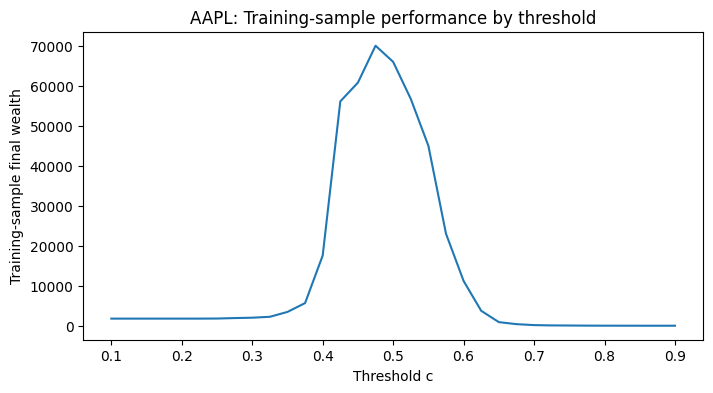

In [7]:
best_c = train_results.iloc[0]["threshold"]
print(f"Best training threshold: {best_c:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(train_results.sort_values("threshold")["threshold"],
         train_results.sort_values("threshold")["final_wealth"])
plt.xlabel("Threshold c")
plt.ylabel("Training-sample final wealth")
plt.title(f"{ticker}: Training-sample performance by threshold")
plt.show()

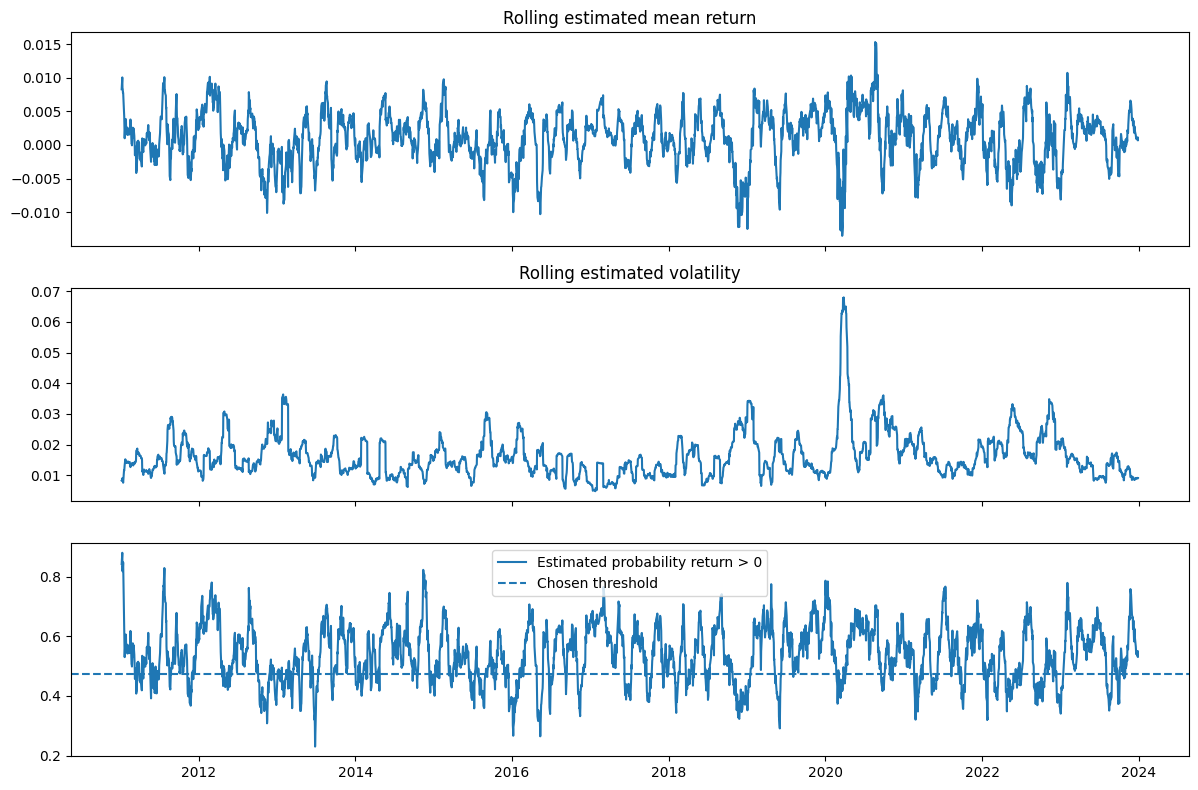

In [8]:
# Visualize the estimated signals in the training data
final_signal_train = get_signal(df_pred["prob_up"], best_c)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df_pred.index, df_pred["mu_hat"])
axes[0].set_title("Rolling estimated mean return")

axes[1].plot(df_pred.index, df_pred["sigma_hat"])
axes[1].set_title("Rolling estimated volatility")

axes[2].plot(df_pred.index, df_pred["prob_up"], label="Estimated probability return > 0")
axes[2].axhline(best_c, linestyle="--", label="Chosen threshold")
axes[2].legend()

plt.tight_layout()
plt.show()

In [9]:
# Holdout evaluation: apply the tuned rule to 2024
returns_test = returns_matrix.loc[returns_matrix.index.year == 2024, ticker].copy()

mu_hat_test = returns_test.rolling(window, min_periods=5).mean()
sigma_hat_test = returns_test.rolling(window, min_periods=5).std()

test_pred = pd.DataFrame({
    "mu_hat": mu_hat_test,
    "sigma_hat": sigma_hat_test
}, index=returns_test.index).dropna()

test_pred["prob_up"] = 1 - norm.cdf(0, loc=test_pred["mu_hat"], scale=test_pred["sigma_hat"])
signal_test = get_signal(test_pred["prob_up"], best_c)

wealth_policy = backtest_policy(returns_test.loc[test_pred.index], signal_test)
wealth_buyhold = 100 * (1 + returns_test.loc[test_pred.index]).cumprod()

comparison = pd.DataFrame({
    "Policy": wealth_policy,
    "Buy and hold": wealth_buyhold
})

comparison.tail()

,Policy,Buy and hold
date,,
2024-12-24,157.531778,143.207982
2024-12-26,158.032099,143.662811
2024-12-27,155.939438,141.760428
2024-12-30,153.871213,139.880259
2024-12-31,152.785190,138.892985


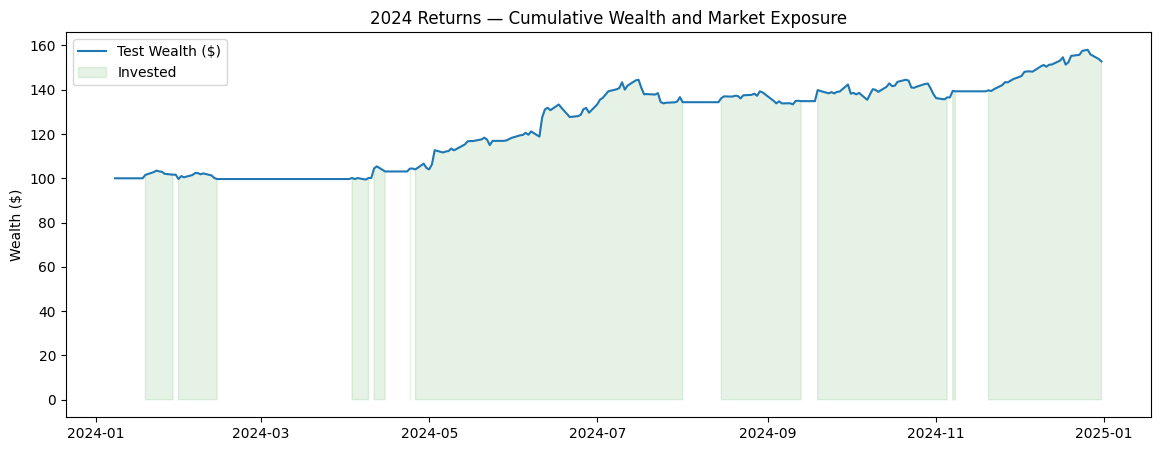

In [10]:
#Visualize policy in hold out period
plt.figure(figsize=(14,5))
plt.plot(wealth_policy.index, wealth_policy, label='Test Wealth ($)')
plt.fill_between(wealth_policy.index, 0, wealth_policy, where=signal_test.astype(bool), color='green', alpha=0.1, label='Invested')
plt.ylabel('Wealth ($)')
plt.title('2024 Returns — Cumulative Wealth and Market Exposure')
plt.legend()
plt.show()

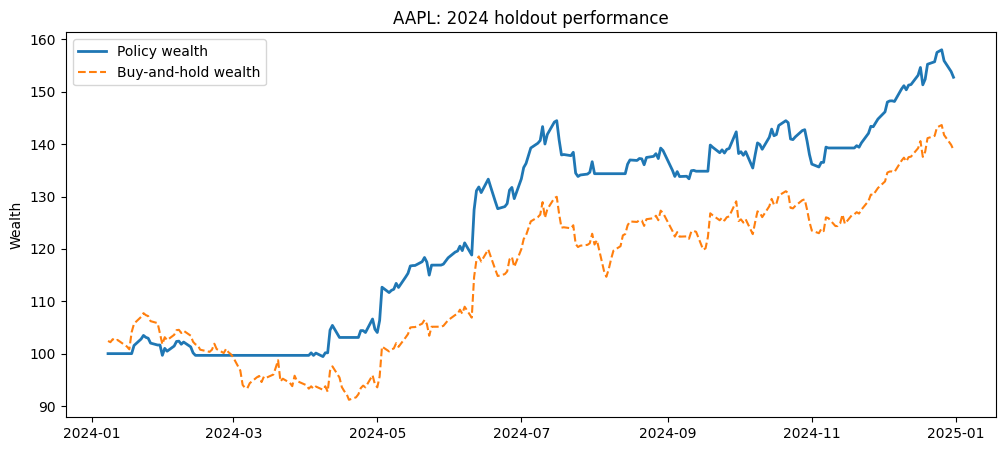

Final wealth with policy:     $152.79
Final wealth with buy/hold:   $138.89
Fraction of holdout days invested: 0.722


In [11]:
plt.figure(figsize=(12, 5))
plt.plot(comparison.index, comparison["Policy"], label="Policy wealth", linewidth=2)
plt.plot(comparison.index, comparison["Buy and hold"], label="Buy-and-hold wealth", linestyle="--")
plt.title(f"{ticker}: 2024 holdout performance")
plt.ylabel("Wealth")
plt.legend()
plt.show()

print(f"Final wealth with policy:     ${comparison['Policy'].iloc[-1]:.2f}")
print(f"Final wealth with buy/hold:   ${comparison['Buy and hold'].iloc[-1]:.2f}")
print(f"Fraction of holdout days invested: {signal_test.mean():.3f}")

## Set-up Questions

---

**Question 1.** In plain language, what is the baseline policy doing? What information is used to decide whether to invest, and what business objective is the threshold tuning step implicitly trying to optimize?

---

**Question 2.** Compare the policy to buy-and-hold on the 2024 holdout period. Does the policy look attractive? In answering, go beyond final wealth. Comment on at least one additional consideration such as market exposure, volatility, drawdowns, turnover, or plausibility of the underlying signal.

---

**Question 3.** Why is it important that the threshold is chosen using pre-2024 data and then evaluated on 2024 separately? What kinds of mistakes would lead to data leakage or an overly optimistic assessment of performance?

---


## General Portfolio Weights

It is important to see that the baseline problem above is already a portfolio choice problem. The policy does not merely say "buy" or "do not buy." It chooses weights on two assets: a risky stock and cash.

If the signal says invest, then the portfolio is

$$
(w_{\text{stock}}, w_{\text{cash}}) = (1,0).
$$

If the signal says stay out, then the portfolio is

$$
(w_{\text{stock}}, w_{\text{cash}}) = (0,1).
$$

A natural generalization is to allow more flexible weights. For example, you could choose

$$
(w_{\text{stock}}, w_{\text{cash}}) = (0.7, 0.3)
$$

instead of forcing an all-or-nothing decision. With many assets, you might choose a vector

$$
(w_1, \ldots, w_J)
$$

with $\sum_{j=1}^J w_j = 1$.

[Aside: It is perfectly reasonable to impose $w_j \ge 0$ for all $j$ as we do in the code blocks below. You could also consider a broader problem where you allow shorting of assets.]

The code below gives a small illustration of how a weighted portfolio differs from the binary benchmark. Here, we consider a portfolio consisting of two equities; that is, we do not consider cash or another *safe* asset.

In [12]:
ret1_series = returns_matrix.loc[returns_matrix.index.year == 2024, 'AAPL']
ret2_series = returns_matrix.loc[returns_matrix.index.year == 2024, 'ADBE']

In [13]:
def compute_features(returns, window=20):
    mu_hat = returns.rolling(window).mean()
    sigma_hat = returns.rolling(window).std()
    sharpe_hat = mu_hat / (sigma_hat + 1e-8)
    return mu_hat, sigma_hat, sharpe_hat

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)

def compute_weights(mu, sigma, sharpe, alpha, beta, delta):
    score = alpha * mu + beta * sigma + delta * sharpe
    return softmax(score)

In [14]:
data = pd.DataFrame({
    'ret_asset1': ret1_series,
    'ret_asset2': ret2_series
})

# Compute features for each asset
data['mu1'], data['sigma1'], data['sharpe1'] = compute_features(data['ret_asset1'])
data['mu2'], data['sigma2'], data['sharpe2'] = compute_features(data['ret_asset2'])

# Stack features for softmax policy
features = data[['mu1', 'mu2', 'sigma1', 'sigma2', 'sharpe1', 'sharpe2']].dropna()
mu = features[['mu1', 'mu2']].values
sigma = features[['sigma1', 'sigma2']].values
sharpe = features[['sharpe1', 'sharpe2']].values

In [15]:
# Set policy parameters
alpha, beta, delta = 1.0, -0.5, 0.5

# Calculate weights
weights = compute_weights(mu, sigma, sharpe, alpha, beta, delta)

# Portfolio returns
data = data.iloc[-weights.shape[0]:]
data['port_ret'] = (weights * data[['ret_asset1', 'ret_asset2']].values).sum(axis=1)
data['wealth'] = (1 + data['port_ret']).cumprod()

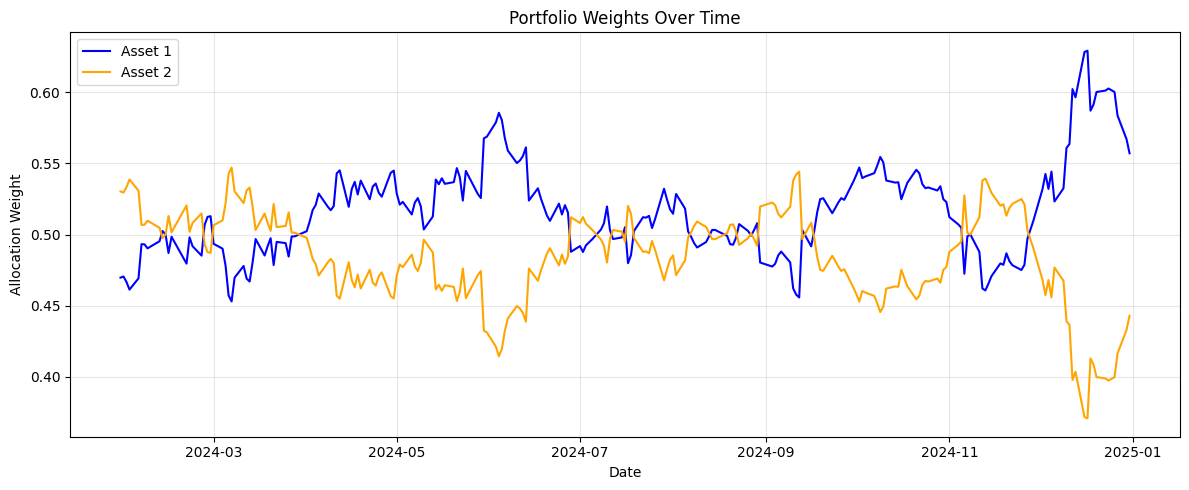

In [16]:
weights_df = pd.DataFrame(weights, columns=["Asset 1", "Asset 2"])
weights_df.index = data.index[-weights.shape[0]:]

plt.figure(figsize=(12, 5))
plt.plot(weights_df.index, weights_df['Asset 1'], label='Asset 1', color='blue')
plt.plot(weights_df.index, weights_df['Asset 2'], label='Asset 2', color='orange')
plt.title('Portfolio Weights Over Time')
plt.xlabel('Date')
plt.ylabel('Allocation Weight')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Final portfolio wealth: $103.01


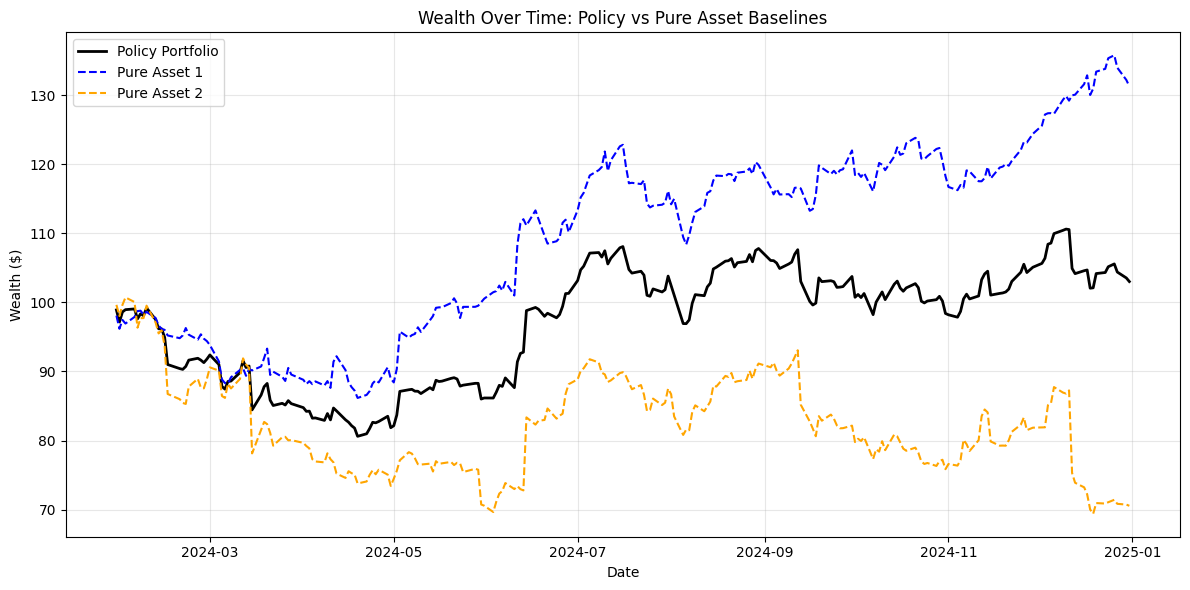

In [17]:
# Set starting wealth
starting_wealth = 100

# Calculate cumulative wealth
data['wealth'] = starting_wealth * (1 + data['port_ret']).cumprod()

wealth_asset1 = starting_wealth * (1 + data['ret_asset1']).cumprod()

wealth_asset2 = starting_wealth * (1 + data['ret_asset2']).cumprod()

print(f"Final portfolio wealth: ${data['wealth'].iloc[-1]:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(data.index, data['wealth'], label='Policy Portfolio', color='black', linewidth=2)
plt.plot(data.index, wealth_asset1, label='Pure Asset 1', linestyle='--', color='blue')
plt.plot(data.index, wealth_asset2, label='Pure Asset 2', linestyle='--', color='orange')

plt.title('Wealth Over Time: Policy vs Pure Asset Baselines')
plt.xlabel('Date')
plt.ylabel('Wealth ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

**Question 4.** Explain what the code blocks above are doing. What information is used to decide how much to invest in each asset? What are the *policy parameters* (alpha, beta, delta)? Does it make sense to fix these parameters as we do in the code above? Can you provide a rationale that would justify these choices in business terms? Looking at the portfolio returns relative to the returns on the two underlying assets, is there a reason one might prefer holding the portfolio instead of simply holding asset 2?

---




In [18]:
train_port = pd.DataFrame({
    'ret_asset1': returns_matrix.loc[returns_matrix.index.year != 2024, 'AAPL'],
    'ret_asset2': returns_matrix.loc[returns_matrix.index.year != 2024, 'ADBE']
}).dropna()

# Compute rolling features using training data only
train_port['mu1'], train_port['sigma1'], train_port['sharpe1'] = compute_features(train_port['ret_asset1'])
train_port['mu2'], train_port['sigma2'], train_port['sharpe2'] = compute_features(train_port['ret_asset2'])

train_features = train_port[['mu1', 'mu2', 'sigma1', 'sigma2', 'sharpe1', 'sharpe2']].dropna()

mu_train = train_features[['mu1', 'mu2']].values
sigma_train = train_features[['sigma1', 'sigma2']].values
sharpe_train = train_features[['sharpe1', 'sharpe2']].values

train_port = train_port.loc[train_features.index].copy()
asset_returns_train = train_port[['ret_asset1', 'ret_asset2']].values

def negative_log_final_wealth(params):
    alpha, beta, delta = params
    weights = compute_weights(mu_train, sigma_train, sharpe_train, alpha, beta, delta)
    port_ret = (weights * asset_returns_train).sum(axis=1)

    # log(final wealth) = sum_t log(1 + portfolio return_t)
    # We clip very slightly away from zero to avoid numerical problems
    log_wealth = np.sum(np.log(np.clip(1 + port_ret, 1e-8, None)))
    return -log_wealth

result = minimize(
    negative_log_final_wealth,
    x0=np.array([1.0, -0.5, 0.5]),
    method='L-BFGS-B'
)

alpha_opt, beta_opt, delta_opt = result.x

weights_opt = compute_weights(mu_train, sigma_train, sharpe_train, alpha_opt, beta_opt, delta_opt)
train_port['port_ret_opt'] = (weights_opt * asset_returns_train).sum(axis=1)
train_port['wealth_opt'] = (1 + train_port['port_ret_opt']).cumprod()

print(f"Optimization converged: {result.success}")
print(f"alpha_hat = {alpha_opt:.4f}")
print(f"beta_hat  = {beta_opt:.4f}")
print(f"delta_hat = {delta_opt:.4f}")
print(f"Log final wealth (training sample): {-result.fun:.4f}")
print(f"Final wealth from $1 invested (training sample): {train_port['wealth_opt'].iloc[-1]:.4f}")

display(train_port[['ret_asset1', 'ret_asset2', 'port_ret_opt', 'wealth_opt']].head())


Optimization converged: True
alpha_hat = -107.5246
beta_hat  = 1344.3879
delta_hat = 898.3856
Log final wealth (training sample): 8.1821
Final wealth from $1 invested (training sample): 3576.4586


,ret_asset1,ret_asset2,port_ret_opt,wealth_opt
date,,,,
2011-01-31,0.009580,0.017236,0.017236,1.017236
2011-02-01,0.016828,0.013918,0.013918,1.031394
2011-02-02,-0.002058,-0.002387,-0.002387,1.028932
2011-02-03,-0.002556,0.002991,0.002991,1.032009
2011-02-04,0.008910,-0.005070,0.008910,1.041205


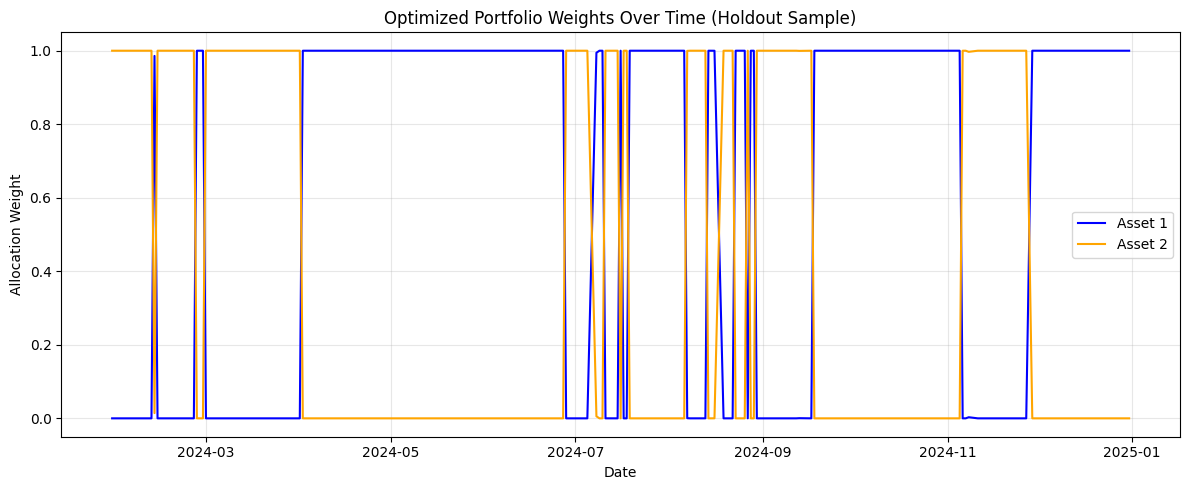

Final portfolio wealth on holdout sample: $116.35


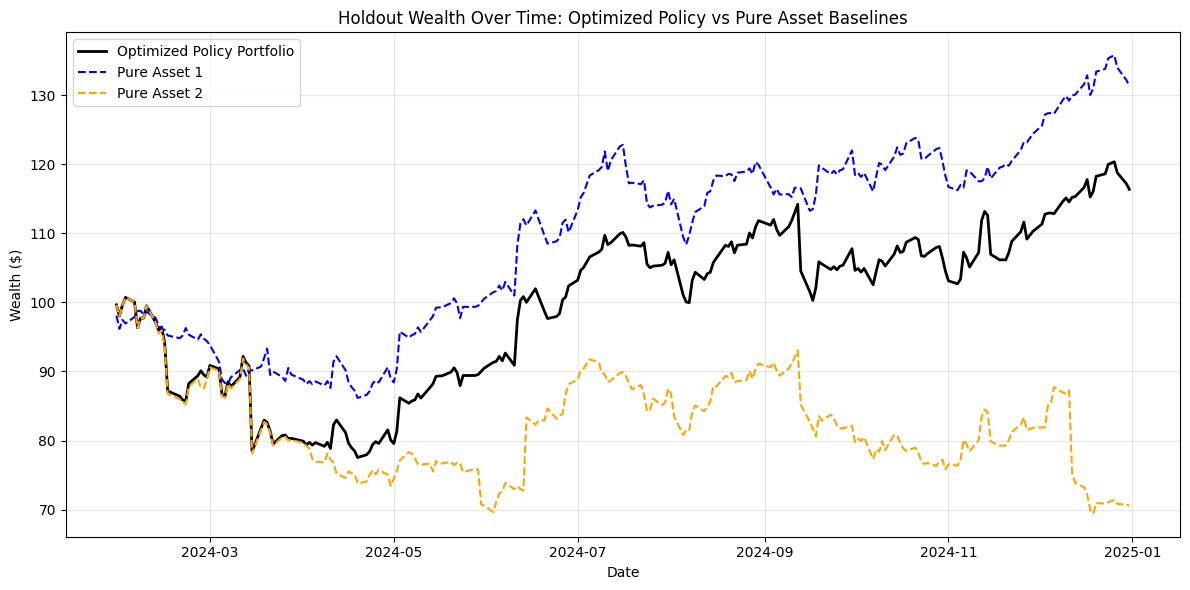

In [19]:
# Evaluate the optimized policy out of sample on the 2024 holdout sample

holdout_port = pd.DataFrame({
    'ret_asset1': returns_matrix.loc[returns_matrix.index.year == 2024, 'AAPL'],
    'ret_asset2': returns_matrix.loc[returns_matrix.index.year == 2024, 'ADBE']
}).dropna()

# Compute rolling features on the holdout sample
holdout_port['mu1'], holdout_port['sigma1'], holdout_port['sharpe1'] = compute_features(holdout_port['ret_asset1'])
holdout_port['mu2'], holdout_port['sigma2'], holdout_port['sharpe2'] = compute_features(holdout_port['ret_asset2'])

holdout_features = holdout_port[['mu1', 'mu2', 'sigma1', 'sigma2', 'sharpe1', 'sharpe2']].dropna()

mu_holdout = holdout_features[['mu1', 'mu2']].values
sigma_holdout = holdout_features[['sigma1', 'sigma2']].values
sharpe_holdout = holdout_features[['sharpe1', 'sharpe2']].values

holdout_port = holdout_port.loc[holdout_features.index].copy()
asset_returns_holdout = holdout_port[['ret_asset1', 'ret_asset2']].values

# Calculate optimized weights using the parameters estimated on the training sample
weights_holdout = compute_weights(mu_holdout, sigma_holdout, sharpe_holdout, alpha_opt, beta_opt, delta_opt)

# Portfolio returns on the holdout sample
holdout_port['port_ret_opt'] = (weights_holdout * asset_returns_holdout).sum(axis=1)

# Plot portfolio weights over time
weights_holdout_df = pd.DataFrame(weights_holdout, columns=["Asset 1", "Asset 2"])
weights_holdout_df.index = holdout_port.index

plt.figure(figsize=(12, 5))
plt.plot(weights_holdout_df.index, weights_holdout_df['Asset 1'], label='Asset 1', color='blue')
plt.plot(weights_holdout_df.index, weights_holdout_df['Asset 2'], label='Asset 2', color='orange')
plt.title('Optimized Portfolio Weights Over Time (Holdout Sample)')
plt.xlabel('Date')
plt.ylabel('Allocation Weight')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wealth comparison on the holdout sample
starting_wealth = 100

holdout_port['wealth_opt'] = starting_wealth * (1 + holdout_port['port_ret_opt']).cumprod()
wealth_asset1_holdout = starting_wealth * (1 + holdout_port['ret_asset1']).cumprod()
wealth_asset2_holdout = starting_wealth * (1 + holdout_port['ret_asset2']).cumprod()

print(f"Final portfolio wealth on holdout sample: ${holdout_port['wealth_opt'].iloc[-1]:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(holdout_port.index, holdout_port['wealth_opt'], label='Optimized Policy Portfolio', color='black', linewidth=2)
plt.plot(holdout_port.index, wealth_asset1_holdout, label='Pure Asset 1', linestyle='--', color='blue')
plt.plot(holdout_port.index, wealth_asset2_holdout, label='Pure Asset 2', linestyle='--', color='orange')

plt.title('Holdout Wealth Over Time: Optimized Policy vs Pure Asset Baselines')
plt.xlabel('Date')
plt.ylabel('Wealth ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

**Question 5.** Explain what the two preceding code blocks are doing. Briefly explain how to intepret alpha_hat, beta_hat, delta_hat. Specifically, what do these numbers tell us about features that influence the portfolio weights? [HINT: Look at the figures produced by the second code block, what are we effectively doing when we use the optimized policy.]

---

**Question 6.** Of the policies considered (buy/hold a single asset, form a portfolio between a single asset and cash that is all or nothing, form a portfolio across two assets with optimized weights), which would you recommend and why?

---



## Main Question Prompt

The policies explored above are incredibly simple. Historical data is incorporated exclusively via an ad hoc choice of a particular rolling mean and standard deviation. These baseline rules do not adapt flexibly to the structure of the data.

Your task now is to improve upon these baseline policies. You may consider portfolios consisting of (any subset of) the entire universe of assets provided in the data and a risk free asset. For simplicity, you can take the risk free asset as cash and assign it a return of 0. You may use any combination of supervised and unsupervised learning for using information available at time $t$ when forming your policy.

There is no single correct answer. A strong solution will combine thoughtful model design, careful out-of-sample evaluation, and a clear discussion of business relevance.

At a minimum, your solution should do the following:

1. **Choose a policy objective.**  
Decide what the policy is trying to optimize. Possibilities include final wealth, average return, Sharpe ratio, downside risk, drawdown control, or some combination. You should justify your choice from the perspective of an investment business.

2. **Build a richer decision rule.**  
Start from the baseline workflow above and improve it. For example, you might:
   - use additional lagged-return features,
   - vary the lookback window,
   - use multiple assets rather than one,
   - map signals into portfolio weights rather than a binary action,
   - rank assets and allocate more weight to the most attractive names,
   - use a simple supervised learning model to map features into expected returns and then convert those into weights,
   - or impose practical constraints such as turnover limits, diversification constraints, or risk controls.

3. **Evaluate out of sample.**  
Be explicit about how you separate training, tuning, and evaluation. If you tune many policy choices, explain how you avoid simply overfitting to one historical period.

4. **Assess robustness.**  
Show that your conclusions are not entirely driven by one arbitrary choice. For example, check sensitivity to the asset universe, training window, evaluation period, or objective function.

---

**Question 7.** Develop and justify your improved policy. Explain:
- what features enter your decision rule,
- how weights are chosen,
- what constraints are imposed,
- what tuning choices were made,
- and why your policy should be better aligned with the business objective than the baseline rule.

If you wish, you may extend the analysis to consider short positions. However, doing so is not necessary and would require careful discussion of realism, leverage, implementation, and risk.

---

**Question 8.** Compare your preferred policy to reasonable benchmarks. For portfolio choice, a natural benchmark is to an equally-weighted portfolio. You might also consider the simple baseline in/out strategy above.

Discuss both performance and interpretability.

---

**Question 9.** Finally, and most importantly, prepare a slide deck suitable for a 10 minute presentation to an investment committee or portfolio manager.

Your presentation should include, at a minimum:

1. The business problem and objective.
2. Why the baseline binary equity/cash rule is too restrictive.
3. Your recommended allocation strategy and how the weights are chosen in plain language.
4. Out-of-sample evidence on performance.
5. Any important caveats.

The audience is willing to use data-driven decision rules, but it does not want a highly technical lecture. Your goal is to persuade a sophisticated business audience that your proposed allocation strategy is sensible, interpretable, while being honest about its limitations.

---
---
---

# Case 2: Contextual Bandits for Dynamic Pricing

## Set-up

Imagine you work on an analytics team for a retailer that must repeatedly choose prices for arriving households. The firm does not simply want a single "best" static price. Instead, it wants a pricing system that can learn over time while adapting prices to observable customer characteristics.

This case uses the same retail pricing environment that appeared in earlier problem sets, but the business question is now different. Rather than predicting demand or estimating a treatment effect, your goal is to study a sequential decision problem: how should a firm price when it must learn from ongoing interactions with customers?

A natural approach is a contextual bandit. Contextual bandits balance two competing goals:

1. **Exploration:** try prices that may be informative,
2. **Exploitation:** use what has already been learned to earn higher profit.

In practice, a pricing team would care about more than raw algorithmic performance. They would also want to understand whether the resulting pricing policy is stable, interpretable, and credible enough to deploy.

In [20]:
import sys
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## Setup Instructions

The code below defaults to running this notebook in **Google Colab**.

If working in Colab, you will need to have the files provided in [PS_5_Contextual_Bandits.zip](https://github.com/chansen776/MBA-ML-Course-Materials/blob/main/Problem%20Sets/Data%20and%20Supplementary%20Files/PS5_Contextual_Bandits.zip) in your google drive. The default workflow below assumes that the files are on your google drive in a directory called **PS5_Contextual_Bandits**. If you use a different folder name or have an alternative path, you will need to update the path in the code cell below.

If you wish to work locally, a local option is also included. Change the switch `USE_COLAB` to `False` and update the paths in the `Local option` to align with your system.

In [21]:
# Default workflow: Google Colab + Google Drive
USE_COLAB = False

# -------------------------------------------------------------------
# If you are using Colab, place the provided `pricing_sim` folder and
# `states_stats.xlsx` file in a folder in Google Drive and point
# CASE_DIR to that folder.
# -------------------------------------------------------------------
if USE_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    CASE_DIR = Path('/content/drive/MyDrive/PS5_Contextual_Bandits')
    sys.path.append(str(CASE_DIR))
    STATE_STATS_PATH = CASE_DIR / 'states_stats.xlsx'

# -------------------------------------------------------------------
# Local option: adapt these paths to match your own folder structure.
# -------------------------------------------------------------------
else:
    CASE_DIR = Path('/Users/nicolasbunjamin/Projects/busn41204_machine_learning/')
    sys.path.append(str(CASE_DIR))
    STATE_STATS_PATH = CASE_DIR / 'Data' / 'Raw' / 'states_stats.xlsx'

SIM_IMPORT_OK = False

try:
    from pricing_sim.market_simulator import RetailMarketSim
    from pricing_sim.households import simulate_households_by_state
    from pricing_sim.utility_functions import beta_behavior, beta_demographics, alpha_demographics
    SIM_IMPORT_OK = True
    print('Imported RetailMarketSim and dependencies.')
except Exception as e1:
    try:
        from market_simulator import RetailMarketSim
        from households import simulate_households_by_state
        from utility_functions import beta_behavior, beta_demographics, alpha_demographics
        SIM_IMPORT_OK = True
        print('Imported RetailMarketSim and dependencies.')
    except Exception as e2:
        print('Could not import RetailMarketSim.')
        print('First error:', e1)
        print('Second error:', e2)

assert SIM_IMPORT_OK, 'Please adapt the import path so the simulator loads correctly.'
assert STATE_STATS_PATH.exists(), f'Could not find {STATE_STATS_PATH}. Update the Drive or local path above.'

Could not import RetailMarketSim.
First error: No module named 'pricing_sim'
Second error: No module named 'market_simulator'


AssertionError: Please adapt the import path so the simulator loads correctly.

## Loading and constructing the household-level data

The simulator needs a household dataset describing the distribution of consumers in the market. The code below loads the state-level inputs, simulates a population of households, and then constructs a simple baseline context vector.

We will begin with only a few context variables. This is deliberate: the goal is to start with a pricing policy that is easy to understand before asking whether richer context improves performance.

In [ ]:
# Generate a household sample for the simulator
state_stats = pd.read_excel(STATE_STATS_PATH)
df_households = simulate_households_by_state(state_stats, total_n=10000)

households_df = df_households.copy()
print('Shape:', households_df.shape)
display(households_df.head())

## Variables to ignore

In the background, we have variables that a firm could not observe to help drive heterogeneity in customer behavior for our simulation: `product_affinity`, `price_sensitivity`, and `ad_sensitivity`.

**DO NOT USE THESE VARIABLES IN BUILDING YOUR PRICING RULE IN WHAT FOLLOWS!!**

In [ ]:
# Basic checks and baseline context construction
required_cols = ['hh_id', 'state', 'log_income', 'age', 'family_size', 'sex', 'race']
missing = [c for c in required_cols if c not in households_df.columns]
assert len(missing) == 0, f'Missing required columns: {missing}'

households_df = households_df.copy()
households_df['log_income_sq'] = households_df['log_income'] ** 2

# Start with a simple context vector.
context_cols = ['log_income', 'log_income_sq']

print('Baseline context columns used:', context_cols)

## Set-up Questions

---

**Question 1.** What is the business decision the firm is making in this case? How is that decision different from the prediction and causal-inference problems in earlier cases?

---

**Question 2.** Why might it be useful to begin with a small context vector such as `log_income` and `log_income_sq` rather than immediately using every available household characteristic?

---



## Choosing simulation parameters

To compare policies fairly, we will keep the environment fixed across runs as much as possible. You may later experiment with the horizon, action set, reward definition, or context variables, but the baseline analysis below uses a common simulation configuration.

**IMPORTANT: As you explore bandits within this case, you will likely want to alter these settings.**

For example, to consider using income, income_squared, and age as context variables, you could define

```
context_cols = ['log_income', 'log_income_sq', 'age']
```

and the run the block below to update the bandit to use this context. (More simply, you could just redefine `COMMON_KWARGS` using the new context variables.) Similarly, if you wanted to look at a richer action space or what happens when you see more time periods (and hence more arrivals and data), you would do that by altering elements here.

**Note that you should interpet `T` as the number of months of deployment/monitoring.**



In [ ]:
# Common simulation configuration
RANDOM_STATE = 123
T = 50
ARRIVAL_RATE = 0.03

BANDIT_ACTIONS = [20, 25, 30, 35, 40]
AB_PRICES = (25.0, 35.0)

beta_demographics = globals().get('beta_demographics', None)
beta_behavior = globals().get('beta_behavior', None)
alpha_demographics = globals().get('alpha_demographics', None)
race_effects = globals().get('race_effects', None)
state_effects = globals().get('state_effects', None)

COMMON_KWARGS = dict(
    households_df=households_df,
    T=T,
    arrival_rate=ARRIVAL_RATE,
    random_state=RANDOM_STATE,
    bandit_actions=BANDIT_ACTIONS,
    context_cols=context_cols,
    ab_prices=AB_PRICES,
    base_price=25.0,
    store_household_panel=True
)

DEMAND_KWARGS = dict(
    beta_demographics=beta_demographics,
    beta_behavior=beta_behavior,
    alpha_demographics=alpha_demographics,
    race_effects=race_effects,
    state_effects=state_effects
)

## Helper functions

The helper functions below make it easier to run multiple policies and compare them on common business metrics.

In [ ]:
# Helper functions
def make_sim(**overrides):
    cfg = COMMON_KWARGS.copy()
    cfg.update(overrides)
    return RetailMarketSim(**cfg)

def run_policy(policy, sim_kwargs=None, run_kwargs=None):
    sim_kwargs = sim_kwargs or {}
    run_kwargs = run_kwargs or {}
    sim = make_sim(**sim_kwargs)
    out = sim.run(policy=policy, **DEMAND_KWARGS, **run_kwargs)
    if isinstance(out, tuple):
        market_df, hh_df = out[0], out[1]
    else:
        market_df, hh_df = out, None
    return market_df, hh_df, sim

def summarize_market(market_df, label):
    return pd.Series({
        "policy": label,
        "periods": market_df["period"].nunique(),
        "total_arrivals": market_df["arrivals"].sum(),
        "total_purchases": market_df["purchases"].sum(),
        "purchase_rate": market_df["purchases"].sum() / market_df["arrivals"].sum() if market_df["arrivals"].sum() > 0 else np.nan,
        "avg_price": market_df["price"].mean(),
        "total_revenue": market_df["revenue"].sum(),
        "total_profit": market_df["profit"].sum(),
        "avg_period_profit": market_df["profit"].mean(),
    })

def add_cumulative_columns(market_df):
    out = market_df.copy()
    out["cum_revenue"] = out["revenue"].cumsum()
    out["cum_profit"] = out["profit"].cumsum()
    return out

def plot_cumulative(metric, results_dict, title=None):
    plt.figure(figsize=(8, 5))
    for label, df in results_dict.items():
        plt.plot(df["period"], df[metric], marker="o", label=label)
    plt.xlabel("Period")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title or metric.replace("_", " ").title())
    plt.legend()
    plt.grid(True)
    plt.show()

def policy_summary_table(results_dict):
    rows = []
    for label, market_df in results_dict.items():
        rows.append(summarize_market(market_df, label))
    return pd.DataFrame(rows).sort_values("total_profit", ascending=False).reset_index(drop=True)

## Benchmark pricing rules

Before studying adaptive pricing, it is useful to compare a few simple benchmark policies. These rules do not attempt to learn a personalized pricing policy in a principled way.

We will consider:

- a fixed-price rule,
- a cost-plus rule (where we have added an arbitrary 30% markup over marginal cost),
- and a random-price rule.

These are not necessarily good long-run business policies, but they provide useful baselines for comparison.

In [ ]:
# Run the benchmark policies
market_fixed, hh_fixed, _ = run_policy('fixed')
market_cost_plus, hh_cost_plus, _ = run_policy('cost_plus')
market_random, hh_random, _ = run_policy('random')

benchmarks = {
    'Fixed': add_cumulative_columns(market_fixed),
    'Cost-plus': add_cumulative_columns(market_cost_plus),
    'Random': add_cumulative_columns(market_random),
}

policy_summary_table(benchmarks)

In [ ]:
# Plot cumulative profit for benchmark policies
plot_cumulative(
    metric='cum_profit',
    results_dict=benchmarks,
    title='Benchmark policies: cumulative profit'
)

# Plot cumulative revenue for benchmark policies
plot_cumulative(
    metric='cum_revenue',
    results_dict=benchmarks,
    title='Benchmark policies: cumulative revenue'
)

## Benchmark Questions
---

**Question 3.** Which benchmark policy performs best on total profit? Why do you think that happens in this environment?

Why can a random pricing policy be useful as a benchmark even if it is not a realistic policy a firm would deploy?

Why might a cost-plus rule, in which the firm charges a markup over marginal cost, still be attractive in practice even if it is not fully optimal?

---

## A baseline contextual bandit

We now want to move away from static pricing and imagine that the firm would like learn about good pricing rules while making decisions. A contextual bandit is a natural approach to dealing with setting. A contextual bandit repeatedly:

1. observes the current customer context,
2. chooses an action,
3. observes a reward,
4. and updates what it has learned.

The simulator uses a *disjoint LinUCB* contextual bandit. For each possible price, the algorithm estimates a separate linear model linking customer context to expected reward. It then adds an *exploration bonus* so that prices with greater uncertainty are more likely to be tried.

---

## The Disjoint LinUCB Algorithm

The idea behind LinUCB is simple:

- The algorithm assumes that expected reward depends linearly on the context variables.
- It estimates a separate model for each possible action (price).
- It chooses the action with the highest upper confidence bound on expected reward.

For each price $a$, the algorithm estimates a model of the form:

$$
\text{Expected reward} = x^\top \theta_a
$$

where

- $x$ is the *context vector* (household characteristics)
- $\theta_a$ are parameters specific to action (price) $a$

When selecting a price, LinUCB computes a *score*:

$$
\text{score}_a =
x^\top \hat{\theta}_a
+
\alpha \sqrt{x^\top A_a^{-1} x}
$$

The score contains two components:

1. **Predicted reward**  
   $x^\top \hat{\theta}_a$

2. **Exploration bonus**  
   $\alpha \sqrt{x^\top A_a^{-1} x}$

The exploration bonus is larger when the algorithm has less information about that action.

This encourages the algorithm to explore prices that are still uncertain.

The term “disjoint” means that the algorithm estimates a separate model for each action (price) rather than sharing parameters across actions.

---

## Key Parameters in the Simulator

The contextual bandit implementation in the simulator includes several parameters that control how the algorithm behaves.

### `bandit_reward`

This determines what the algorithm tries to maximize.

Possible values:

- `"revenue"`  
  reward = price × purchase

- `"profit"`  
  reward = (price − cost) × purchase

Maximizing revenue and maximizing profit may lead to different pricing strategies.

---

### `bandit_alpha`

This controls the amount of exploration.

- Larger values → more exploration
- Smaller values → more exploitation

If `alpha` is very small, the algorithm may quickly commit to one price and stop exploring.  

If `alpha` is very large, the algorithm will try many different prices, which may reduce short-run profits.

---

### `bandit_lambda`

This parameter controls regularization in the linear models.

The algorithm maintains a matrix $A$ that summarizes the information collected so far.  
At the start of the simulation, $A$ is initialized as:

$$
A = \lambda I
$$

where $I$ is the identity matrix.

A larger `lambda` means:

- stronger regularization
- more stable estimates early in the simulation

In practice, this parameter mainly affects how cautious the algorithm is when little data is available.

---

In this notebook, we will start by letting the algorithm optimize *profit*. You will later assess whether the learned pricing behavior appears sensible and whether the algorithm seems to improve over time.

In [ ]:
# Contextual bandit run
market_bandit, hh_bandit, sim_bandit = run_policy(
    'contextual_bandit',
    sim_kwargs=dict(
        bandit_reward='profit',
        bandit_alpha=10.0,
        bandit_lambda=.5
    )
)

bandit_results = {'Contextual bandit': add_cumulative_columns(market_bandit)}
all_results = {**benchmarks, **bandit_results}

policy_summary_table(all_results)

In [ ]:
plot_cumulative(
    metric='cum_profit',
    results_dict=all_results,
    title='All policies: cumulative profit'
)

plot_cumulative(
    metric='cum_revenue',
    results_dict=all_results,
    title='All policies: cumulative revenue'
)

## Interpreting the learned pricing policy

The idea of a contextual bandit is to learn a pricing policy. Before deploying, we'd ideally understand if the resulting pricing behavior makes business sense. The next code blocks give a simple starting point for interpreting how prices vary across households and over time.

In [ ]:
# Price heterogeneity under the bandit
assert hh_bandit is not None, 'Need household panel from bandit run.'

bandit_eval = hh_bandit.copy()

if 'log_income' in bandit_eval.columns:
    bandit_eval['income_quartile'] = pd.qcut(
        bandit_eval['log_income'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop'
    )
    display(
        bandit_eval.groupby('income_quartile')[['price', 'purchase', 'reward']]
        .mean()
        .round(3)
    )

# Average purchase rate and reward by offered price
price_summary = (
    bandit_eval.groupby('price')[['purchase', 'reward']]
    .mean()
    .sort_index()
    .round(3)
)
display(price_summary)

In [ ]:
# Price frequencies over time
price_shares = (
    bandit_eval.groupby(['period', 'price'])
    .size()
    .unstack(fill_value=0)
)
price_shares = price_shares.div(price_shares.sum(axis=1), axis=0)

display(price_shares.head())

plt.figure(figsize=(10, 6))
for col in price_shares.columns:
    plt.plot(price_shares.index, price_shares[col], marker='o', label=f'Price {col}')
plt.xlabel('Period')
plt.ylabel('Share of offers')
plt.title('Bandit: price shares over time')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [ ]:
# Compare starting and learned LinUCB coefficients by action (price)

bandit = sim_bandit.bandit
actions = bandit.actions
row_labels = ["intercept"] + sim_bandit.context_cols

coef_table = {}

for action in actions:
    # Starting values: all coefficients begin at 0
    start_theta = np.zeros(len(row_labels))

    # Final learned coefficients: theta = A^{-1} b
    final_theta = np.linalg.solve(bandit.A[action], bandit.b[action])

    coef_table[(f"price = {action}", "start")] = start_theta
    coef_table[(f"price = {action}", "final")] = final_theta

coef_df = pd.DataFrame(coef_table, index=row_labels)

# Make sure columns appear as [start, final] within each action
coef_df = coef_df.reindex(
    columns=pd.MultiIndex.from_tuples(
        [(f"price = {action}", stage) for action in actions for stage in ["start", "final"]]
    )
)

display(coef_df.round(3))

## Questions on the baseline bandit

---

**Question 4.** Does the contextual bandit appear to learn over time? What evidence do you see in the cumulative profit plot and in the price-share plot? How do we think about the coefficient table and what does it tell us?

Why can a contextual bandit outperform a simple static pricing policy in this environment?

---

**Question 5.** What does the bandit pricing rule look like? Does the basline bandit policy appear to price differently for different households? Explain.

---

## Tuning exploration

The LinUCB score combines an estimated expected reward with an uncertainty bonus. The parameter `alpha` controls the weight on that uncertainty bonus.

- Low `alpha` means less exploration.
- High `alpha` means more exploration.

A good pricing system should learn enough to improve over time without sacrificing too much short-run profit.

In our baseline above, we set alpha = 10. Here, we look at performance for different values.

In [ ]:
# Sweep over different exploration values
alpha_grid = [0.25, 1.0, 5]

alpha_runs = {}
alpha_summary_rows = []

for alpha in alpha_grid:
    mkt, hh, _ = run_policy(
        'contextual_bandit',
        sim_kwargs=dict(
            bandit_reward='profit',
            bandit_alpha=alpha,
            bandit_lambda=1.0
        )
    )
    mkt = add_cumulative_columns(mkt)
    alpha_runs[f'alpha={alpha}'] = mkt
    alpha_summary_rows.append(summarize_market(mkt, f'alpha={alpha}'))

alpha_summary = pd.DataFrame(alpha_summary_rows).sort_values('total_profit', ascending=False)
alpha_summary.reset_index(drop=True)

In [ ]:
plot_cumulative(
    metric='cum_profit',
    results_dict=alpha_runs,
    title='Contextual bandit: cumulative profit by alpha'
)

plot_cumulative(
    metric='cum_revenue',
    results_dict=alpha_runs,
    title='Contextual bandit: cumulative revenue by alpha'
)

## Exploration Questions

---

**Question 6.** Which value of `alpha` performs best in your simulation? Why might too little exploration or too much exploration hurt performance?

How would you explain the exploration–exploitation tradeoff in business language?

---

## Main Question Prompt

Up to this point, you have worked with a baseline contextual bandit implementation that uses a simple context vector and a fixed set of algorithm parameters. This is only a starting point.

In practice, firms deploying adaptive decision systems must make a number of modeling and implementation choices. These choices affect how quickly the algorithm learns, how stable its decisions are, and whether the resulting policy is understandable and acceptable to business stakeholders. The goal of the remainder of this problem is for you to explore these choices within our simulated environment to get some sense of the tradeoffs.

(Aside: In practice, prototyping in simulation environments designed to approximate reality is a pretty good idea.)

Your task is now to extend the contextual bandit analysis and evaluate how useful the resulting pricing strategy appears to be from a business perspective.

There is no single correct answer. A strong solution will:

- think carefully about how the contextual bandit learns from data,
- explore tradeoffs between exploration and exploitation,
- investigate how sensitive results are to modeling choices,
- and connect the algorithm’s behavior to a concrete business interpretation.

A natural set of extensions would include:

- expanding the context vector by including additional household variables,
- modifying the bandit action space,
- modifying the simulation horizon,
- evaluating stability using different random seeds,
- comparing different values of `alpha` and `lambda`,
- studying how the pricing policy changes across customer groups.

If you have another idea you want to implement, feel free to do that.

The ultimate goal of the problem is to help you understand tradeoffs between complexity of the context vector and action space, how those related to the amount of data you have (captured by horizon in our setting), the overall role of exploration and exploitation, and to help you think about how one can usefully talk about learned policies in this environment.

---

**Question 7.** Starting from the baseline contextual bandit analysis above, develop an extension that investigates how the algorithm performs under alternative design choices. Your answer should do all of the following:

1. Choose extensions from the list above and clearly explain what aspect of the contextual bandit you are trying to evaluate.

2. Implement the extensions and compare results with the baseline specification.

3. Based on your analysis, propose a *simple rule or configuration* that appears to perform well in this environment. Explain why this rule works and what tradeoffs it reflects.

Be explicit about:

- what the algorithm is optimizing,
- how you evaluate success (profit, revenue, stability, learning speed),
- and what evidence supports your conclusions.

---

**Question 8.** Finally (and most importantly), prepare a short presentation suitable for a 10 minute briefing to a pricing or analytics leadership team.

You should assume that the audience is interested in the business implications of adaptive pricing but may not be familiar with contextual bandit algorithms. The firm currently relies on static pricing rules informed by small scale A/B tests. Imagine that your goal is to provide the leadership with useful information as they consider developing a more systematic algorithmic pricing rule. You may assume that the simulation above was designed based on data provided by the firm based on its previous small scale pricing experiments, historical purchase behavior, and conversations with firm leadership about the business environment.

Your presentation should include, at a minimum:

1. **Statement of the business objective.**  
   Why might a firm use contextual bandits rather than static pricing rules or traditional A/B testing?

2. **Discussion of what you learned in simulation and why it may (or may not) be useful.**  
   E.g., what pricing patterns or policies did the bandit discover? How do they relate to customer characteristics? What did you learn about context, tuning, and duration/data? (Recall that `T` is the number of months of deployment.)

3. **Implentation considerations, limitations, risks.**  
   What challenges might arise when explaining or deploying this system in practice? What guardrails and monitoring should the firm consider if it did deploy a learning agent for algorithmic pricing? Are there considerations for short vs long term profitability?

